In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../")))
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from qdrant_client import QdrantClient
from sentence_transformers import SentenceTransformer
from groq import Groq
from db.qdrant_setup import COLLECTION_NAME
from dotenv import load_dotenv
import qdrant_client as qc


d:\newthings\StructRAG\rag-env\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
d:\newthings\StructRAG\rag-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv() 

qdrant = QdrantClient(path="./qdrant_storage")
embed_model = SentenceTransformer("all-MiniLM-L6-v2")
groq_client  = Groq(api_key=os.getenv("GROQ_API_KEY"))


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7605.20it/s]


In [3]:
# ── State ─────────────────────────────────────────────────────────
class RAGState(TypedDict):
    question: str
    query_vector: List[float]
    retrieved_chunks: List[dict]
    relevance_scores: List[str]     # "relevant" | "irrelevant" per chunk
    rewrite_count: int              # prevent infinite loops
    prompt: str
    answer: str
    hallucination_check: str  

In [4]:
# ── Node 1: Embed the question ────────────────────────────────────
def embed_node(state: RAGState):
    print(f"\n🔍 Embedding question: {state['question']}")

    vector = embed_model.encode(state["question"]).tolist()

    return {"query_vector": vector}

def retrieve_node(state: RAGState, top_k: int = 2):
    results = qdrant.query_points(
        collection_name=COLLECTION_NAME,
        query=state["query_vector"],   # ← pass vector directly
        limit=top_k,
        with_payload=True,
    ).points                           # ← .points gives the list

    chunks = []
    for hit in results:
        chunks.append({
            "text": hit.payload.get("text"),
            "heading": hit.payload.get("heading"),
            "page_start": hit.payload.get("page_start"),
            "score": round(hit.score, 4),
        })

    print(f"\n📄 Retrieved {len(chunks)} chunks:")
    for i, c in enumerate(chunks, 1):
        print(f"  {i}. [score={c['score']}] "
              f"{c['heading'] or 'No heading'} | "
              f"Page {c['page_start']} | "
              f"{c['text'][:80]}...")

    return {"retrieved_chunks": chunks}



def grade_docs_node(state: RAGState):
    scores = []
    for chunk in state["retrieved_chunks"]:
        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{
                "role": "user",
                "content": f"""
                    You are a retrieval evaluator.
                    A document is relevant if it contains information
                    that helps answer the question directly or partially.
                    Question: {state['question']}
                    Document: {chunk['text'][:400]}
                    Answer ONLY 'relevant' or 'irrelevant'."""
            }],
            temperature=0,
        )
        scores.append(response.choices[0].message.content.strip().lower())
    
    print(f"📊 Relevance scores: {scores}")
    return {"relevance_scores": scores}



def rewrite_node(state: RAGState):
    if state["rewrite_count"] >= 2:          # hard limit on retries
        print("⚠️ Max rewrites reached, using original")
        return {"rewrite_count": state["rewrite_count"]}

    response = groq_client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{
            "role": "user",
            "content": f"""Rewrite this question to improve document retrieval.
Original: {state['question']}
Return ONLY the rewritten question."""
        }],
        temperature=0.3,
    )
    new_q = response.choices[0].message.content.strip()
    new_vec = embed_model.encode(new_q).tolist()
    print(f"🔄 Rewritten: {new_q}")
    return {
        "question": new_q,
        "query_vector": new_vec,
        "rewrite_count": state["rewrite_count"] + 1
    }




def prompt_node(state: RAGState):
    context_parts = []

    for i, chunk in enumerate(state["retrieved_chunks"], 1):
        heading = f"[{chunk['heading']}]" if chunk["heading"] else ""
        page = f"(Page {chunk['page_start']})" if chunk["page_start"] else ""
        context_parts.append(
            f"Chunk {i} {heading} {page}:\n{chunk['text']}"
        )

    context = "\n\n---\n\n".join(context_parts)

    prompt = f"""You are a helpful assistant. Answer the question using ONLY the context below.
If the answer is not in the context, say "I don't know based on the document."

CONTEXT:
{context}

QUESTION:
{state['question']}

ANSWER:"""

    return {"prompt": prompt}




# ── Node 4: LLM response via Groq ────────────────────────────────
def llm_node(state: RAGState):
    print("\n🤖 Answer:\n")

    completion = groq_client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[
            {
                "role": "system",
                "content": "You are a document assistant. Answer only from the provided context."
            },
            {
                "role": "user",
                "content": state["prompt"]
            }
        ],
        temperature=0.2,
        top_p=1,
        reasoning_effort="medium",
        stream=True,
        stop=None
    )

    full_answer = ""
    for chunk in completion:
        token = chunk.choices[0].delta.content or ""
        print(token, end="", flush=True)
        full_answer += token

    print("\n")
    return {"answer": full_answer}



def hallucination_check_node(state: RAGState):
    context = "\n".join(c["text"][:300] for c in state["retrieved_chunks"])
    response = groq_client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{
            "role": "user",
            "content": f"""Is this answer grounded in the context?
Context: {context}
Answer: {state['answer']}
Reply ONLY 'grounded' or 'hallucinated'."""
        }],
        temperature=0,
    )
    result = response.choices[0].message.content.strip().lower()
    print(f"🧠 Hallucination check: {result}")
    return {"hallucination_check": result}

def no_answer_node(state: RAGState):
    print("❌ Question is not relevant to this document.")
    return {"answer": "I don't know based on the document."}

def route_after_grading(state: RAGState):
    if "relevant" in state["relevance_scores"]:
        return "prompt"                    
    if state["rewrite_count"] >= 2:
        return "no_answer"                  

    return "rewrite"            

def route_after_hallucination(state: RAGState):
    if state["hallucination_check"] == "grounded":
        return END
    if state["rewrite_count"] >= 2:
        return END                  # give up gracefully
    return "prompt"                # retry generation

In [5]:
# ── Build Graph ───────────────────────────────────────────────────
graph = StateGraph(RAGState)

graph.add_node("embed",    embed_node)
graph.add_node("retrieve", retrieve_node)
graph.add_node("grade",    grade_docs_node)       # NEW
graph.add_node("rewrite",  rewrite_node)           # NEW
graph.add_node("prompt",   prompt_node)
graph.add_node("llm",      llm_node)
graph.add_node("hallcheck", hallucination_check_node)  # NEW
graph.add_node("no_answer", no_answer_node)

graph.add_edge(START,       "embed")
graph.add_edge("embed",     "retrieve")
graph.add_edge("retrieve",  "grade")

# Branch after grading
graph.add_conditional_edges("grade", route_after_grading, {
    "prompt":  "prompt",
    "rewrite": "rewrite",
    "no_answer": "no_answer", 
})

# Rewrite loops back to embed (re-encode new question)
graph.add_edge("rewrite",   "embed")

graph.add_edge("prompt",    "llm")
graph.add_edge("llm",       "hallcheck")

# Branch after hallucination check
graph.add_conditional_edges("hallcheck", route_after_hallucination, {
    "prompt": "prompt",   # retry generation
    END: END,
})
graph.add_edge("no_answer", END) 
rag_app = graph.compile()

In [6]:
result = rag_app.invoke({
        "question": "who is gandhi?",
        "query_vector": [],
        "retrieved_chunks": [],
        "prompt": "",
        "answer": "",
        "rewrite_count": 0 
    })


print(f"\n✅ Final Answer Stored:\n{result['answer']}")



🔍 Embedding question: who is gandhi?

📄 Retrieved 2 chunks:
  1. [score=0.1062] Restart Apache | Page 3 | sudo /bin/systemctl restart httpd...
  2. [score=0.0749] Step-2 | Page 1 | cd home mkdir directory_name cd mkdir directory_name...
📊 Relevance scores: ['irrelevant', 'irrelevant']
🔄 Rewritten: Who was Mahatma Gandhi and what were his contributions to Indian history?

🔍 Embedding question: Who was Mahatma Gandhi and what were his contributions to Indian history?

📄 Retrieved 2 chunks:
  1. [score=0.1047] Step-2 | Page 1 | cd home mkdir directory_name cd mkdir directory_name...
  2. [score=0.0494] Step-4 | Page 1 | Activate the virtual environment source environment_name/bin/activate Create a d...
📊 Relevance scores: ['irrelevant', 'irrelevant']
🔄 Rewritten: What were the key roles and achievements of Mahatma Gandhi in the context of Indian independence and history?

🔍 Embedding question: What were the key roles and achievements of Mahatma Gandhi in the context of Indian independenc

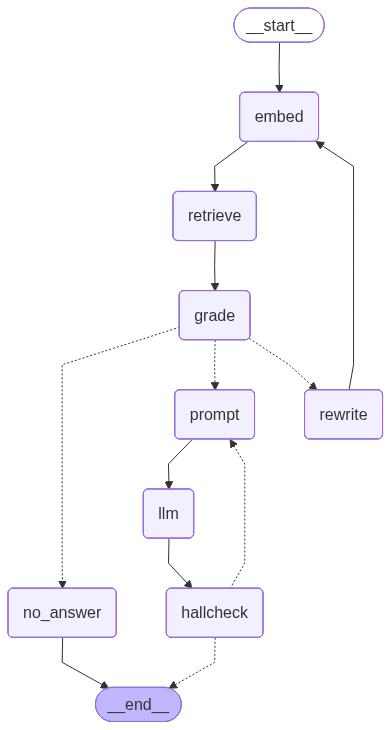

In [7]:
# Visualize graph
from IPython.display import Image, display
display(Image(rag_app.get_graph().draw_mermaid_png()))